In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

# Load UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

# Convert target to binary
y = (y["num"] > 0).astype(int)

print("Dataset shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (303, 13)

Target distribution:
num
0    164
1    139
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing pipeline
preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

Training samples: 242
Testing samples: 61

Training target distribution:
num
0    131
1    111
Name: count, dtype: int64


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison = pd.DataFrame(results)

display(
    comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.9016,0.8667,0.9286,0.8966,0.9610
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9481


In [9]:
import pandas as pd

comparison = pd.DataFrame(results)

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.9016,0.8667,0.9286,0.8966,0.9610
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9481


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            random_state=42
        ))
    ]
)

# Train
rf_pipeline.fit(X_train, y_train)

# Probability of disease = 1
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Test multiple thresholds
threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):

    rf_pred_threshold = (rf_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, rf_pred_threshold),
        "Recall": recall_score(y_test, rf_pred_threshold),
        "F1 Score": f1_score(y_test, rf_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1 Score
0,0.20,0.5957,1.0000,0.7467
1,0.25,0.6364,1.0000,0.7778
2,0.30,0.7000,1.0000,0.8235
3,0.35,0.7500,0.9643,0.8438
4,0.40,0.7941,0.9643,0.8710
5,0.45,0.8438,0.9643,0.9000
6,0.50,0.8667,0.9286,0.8966
7,0.55,0.8667,0.9286,0.8966
8,0.60,0.9259,0.8929,0.9091
9,0.65,0.9583,0.8214,0.8846


In [11]:
from sklearn.metrics import confusion_matrix

# Predictions at both thresholds
pred_050 = (rf_prob >= 0.50).astype(int)
pred_060 = (rf_prob >= 0.60).astype(int)

cm_050 = confusion_matrix(y_test, pred_050)
cm_060 = confusion_matrix(y_test, pred_060)

print("Threshold = 0.50")
print(cm_050)

print("\nThreshold = 0.60")
print(cm_060)

Threshold = 0.50
[[29  4]
 [ 2 26]]

Threshold = 0.60
[[31  2]
 [ 3 25]]


In [12]:
def show_metrics(y_true, y_pred, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    print(f"\nThreshold: {threshold}")
    print("True Negatives :", tn)
    print("False Positives:", fp)
    print("False Negatives:", fn)
    print("True Positives  :", tp)

show_metrics(y_test, pred_050, 0.50)
show_metrics(y_test, pred_060, 0.60)


Threshold: 0.5
True Negatives : 29
False Positives: 4
False Negatives: 2
True Positives  : 26

Threshold: 0.6
True Negatives : 31
False Positives: 2
False Negatives: 3
True Positives  : 25


In [13]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Final predictions at threshold 0.50
final_pred = (rf_prob >= 0.50).astype(int)

# Metrics
print("=" * 55)
print("FINAL RANDOM FOREST EVALUATION")
print("=" * 55)

print(f"Accuracy : {accuracy_score(y_test, final_pred):.4f}")
print(f"Precision: {precision_score(y_test, final_pred):.4f}")
print(f"Recall   : {recall_score(y_test, final_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, final_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_pred,
    target_names=["No Disease", "Disease"]
))

FINAL RANDOM FOREST EVALUATION
Accuracy : 0.9016
Precision: 0.8667
Recall   : 0.9286
F1 Score : 0.8966
ROC-AUC  : 0.9610

Confusion Matrix:
[[29  4]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.94      0.88      0.91        33
     Disease       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importance
importances = rf_pipeline.named_steps["model"].feature_importances_

# Create importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Top Feature Importances:")
display(feature_importance.head(15).round(4))

Top Feature Importances:


,Feature,Importance
12,thal,0.1753
2,cp,0.1464
11,ca,0.1205
7,thalach,0.1105
9,oldpeak,0.0914
0,age,0.0669
8,exang,0.0618
4,chol,0.0585
3,trestbps,0.0572
10,slope,0.0469


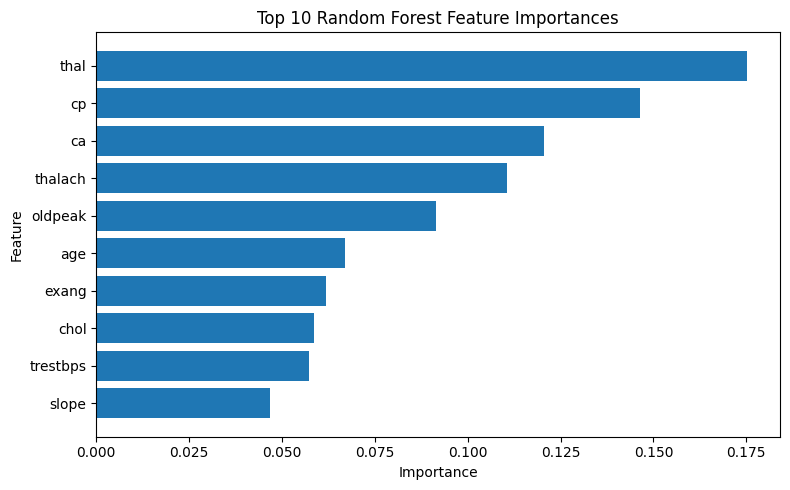

In [15]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
print("Missing values:")
print(X.isnull().sum())

print("\nData types:")
print(X.dtypes)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


## Model Card

### Model Purpose

This project develops a machine learning model for educational heart disease prediction using the UCI Heart Disease dataset.

The model predicts whether a patient belongs to the disease-present or no-disease class.

This model is intended for educational and research purposes only. It is not a medical diagnostic tool and should not be used for clinical decisions.

### Final Model

The final selected model is Random Forest.

At a probability threshold of 0.50:

- Accuracy: 90.16%
- Precision: 86.67%
- Recall: 92.86%
- F1 Score: 89.66%
- ROC-AUC: 96.10%

### Threshold Selection

A threshold of 0.50 was selected for the final screening-oriented evaluation.

At threshold 0.50:
- False Negatives: 2
- False Positives: 4

At threshold 0.60:
- False Negatives: 3
- False Positives: 2

The 0.50 threshold was preferred because missing a disease-positive case can potentially be more concerning in a screening context.

### Error Analysis

A false negative occurs when the model predicts no disease for a patient whose target indicates disease.

A false positive occurs when the model predicts disease for a patient whose target indicates no disease.

For this screening-oriented task, false negatives were given greater consideration because failing to flag a potentially affected patient may have more serious consequences than generating an additional false alarm.

### Feature Interpretation

The most important features according to the Random Forest model were:

1. thal
2. cp
3. ca
4. thalach
5. oldpeak
6. age

These importance values show which variables the model relied on most for prediction. They do not prove that these features cause heart disease.

### Limitations

- The dataset contains only 303 observations.
- The dataset may not represent all patient populations.
- Model performance may vary with different train/test splits.
- Feature importance indicates model reliance, not medical causation.
- The selected threshold may not be appropriate for every clinical setting.
- No clinical validation or prospective testing was performed.
- This model should not replace qualified medical professionals or established diagnostic procedures.

### Responsible Use

This project is an educational machine learning demonstration. Any real-world medical application would require clinical validation, external testing, fairness assessment, regulatory review, monitoring, and qualified medical oversight.